<center><font size=10>Stock News Analysis based on Sentiments</center></font>


<center><p float="center">
  <img src="https://assets.upstox.com/content/assets/images/news/market-crash.jpg"width=700></a>
<center><font size=6>STOCK NEWS </center></font>

## **Problem Statement**

This cell introduces the 'Problem Statement' section of the notebook.

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

This cell provides descriptions for each column in the dataset, including Date, News, Open, High, Low, Close, Volume, and Label (sentiment polarity).

## **Installing and Importing the necessary libraries**

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

In [ ]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

- Connect to Google Drive and read the CSV file into a `pandas` DataFrame so the data can be explored and processed.

In [ ]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/GenAIDataset/stock_news.csv")

In [ ]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

- Before any modeling, the raw data is inspected — its shape, column types, and completeness — so that any cleaning or preprocessing needs are identified early.

###**Checking the first 5 rows**

**Prompt:**

To display the first 5 rows.

In [ ]:
data.head(5)

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

**Prompt:**

To display the last 5 rows.

In [ ]:
data.tail(5)

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

**Prompt:**

To check how many columns and rows in the dataset.

In [ ]:
data.shape

(349, 8)

- The dataset consists of 349 rows and 8 columns

###**Checking for missing values**

**Prompt:**

To check missing values.

In [ ]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


- There's no missing values(NULL values) in the dataset

### **Checking for duplicate values**

**Prompt:**

To check whether the dataset have duplicate values.

In [ ]:
# checking for duplicate values
duplicate_values=data[data.duplicated()]
print("Duplicate_values :")
duplicate_values

Duplicate_values :


,Date,News,Open,High,Low,Close,Volume,Label


In [ ]:
duplicate_values

,Date,News,Open,High,Low,Close,Volume,Label


- There's no duplicted rows in the dataset

## **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) is used here to understand how the news, price, and volume fields behave individually and in relation to one another, and to check whether sentiment labels line up with any visible pattern in price movement before building predictive models.

In [ ]:
# To display the structure of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


- The data has **349 records** across **8 columns**, and there are no missing entries.
- Column types break down as:
  - **Numeric:** `Open`, `High`, `Low`, `Close`, `Volume`, `Label`
  - **Categorical:** `Date`, `News`

In [ ]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

In [ ]:
# To ensure the data type of Date
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    349 non-null    datetime64[ns]
 1   News    349 non-null    object        
 2   Open    349 non-null    float64       
 3   High    349 non-null    float64       
 4   Low     349 non-null    float64       
 5   Close   349 non-null    float64       
 6   Volume  349 non-null    int64         
 7   Label   349 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 21.9+ KB


In [ ]:
# summary statistics for each numeric column
data.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

In [ ]:
#list of numerical columns
num_cols=['Open','High','Low','Close','Volume']

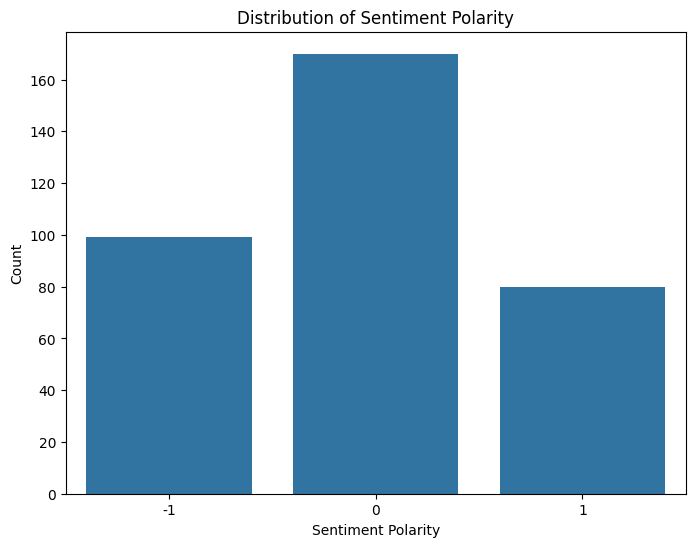

In [ ]:
# Distribution of sentiment polarity
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=data)
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Count')
plt.show()


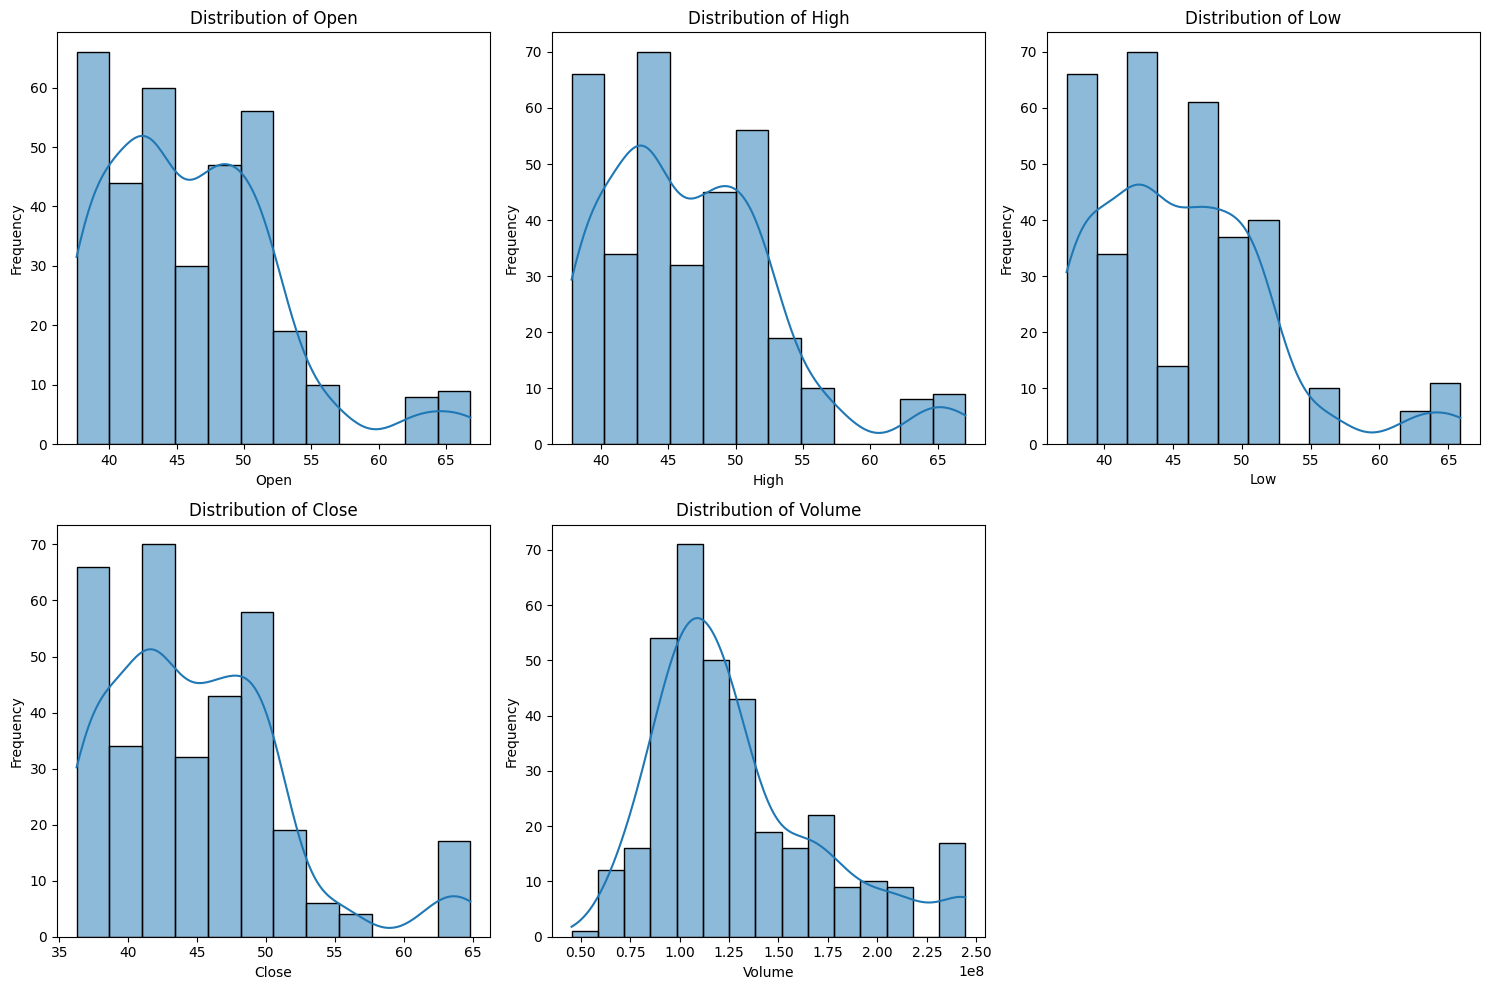

In [ ]:
# Plot Distribution of all Numeric variables
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i) # Arrange plots in 2 rows, 3 columns
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### **Distribution of the length of news content**

In [ ]:
# Compute length of news content (in words)

data['News_length'] = data['News'].apply(lambda x: len(x.split()))
# Summary statistics of news length
data['News_length'].describe()


,News_length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


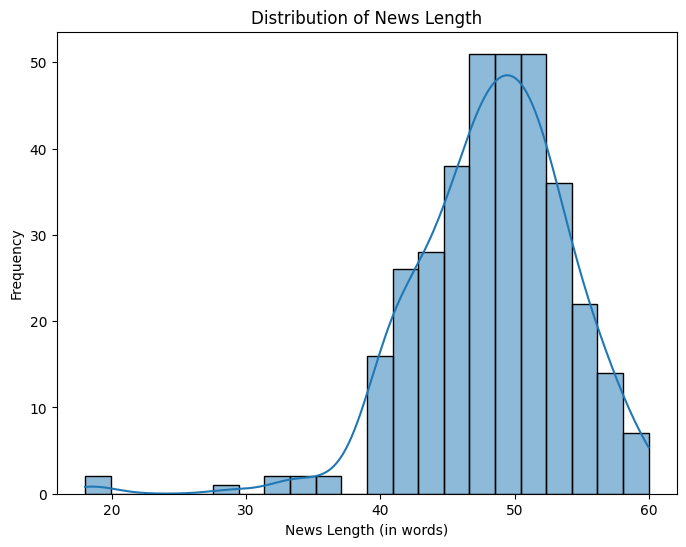

In [ ]:
# Plot distribution
plt.figure(figsize=(8, 6))
sns.histplot(data['News_length'], kde=True)
plt.title('Distribution of News Length')
plt.xlabel('News Length (in words)')
plt.ylabel('Frequency')
plt.show()

### **Monthwise Analysis**

In [ ]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


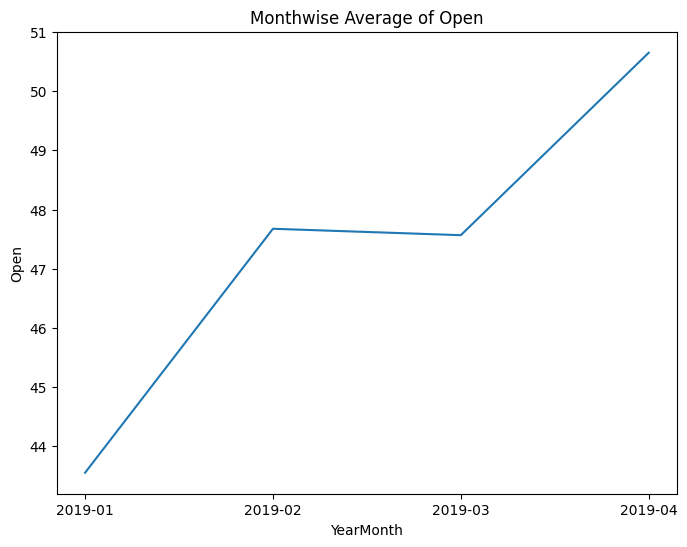

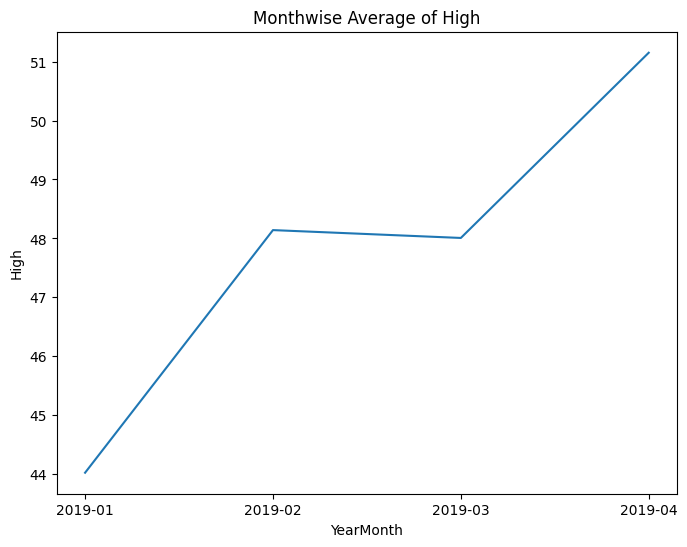

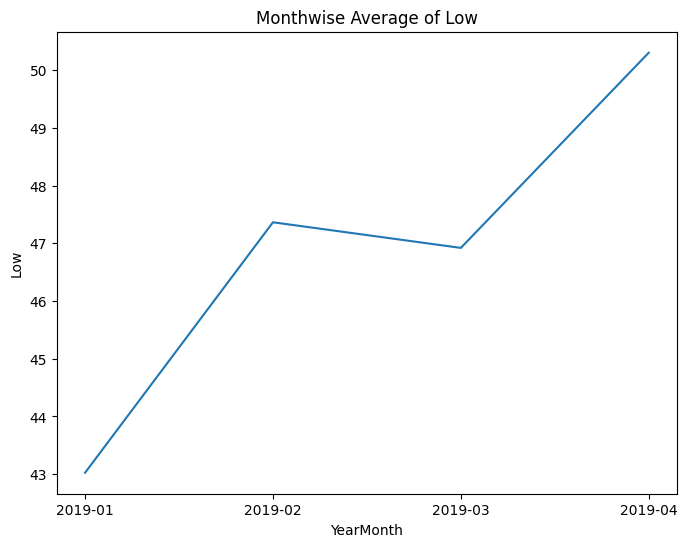

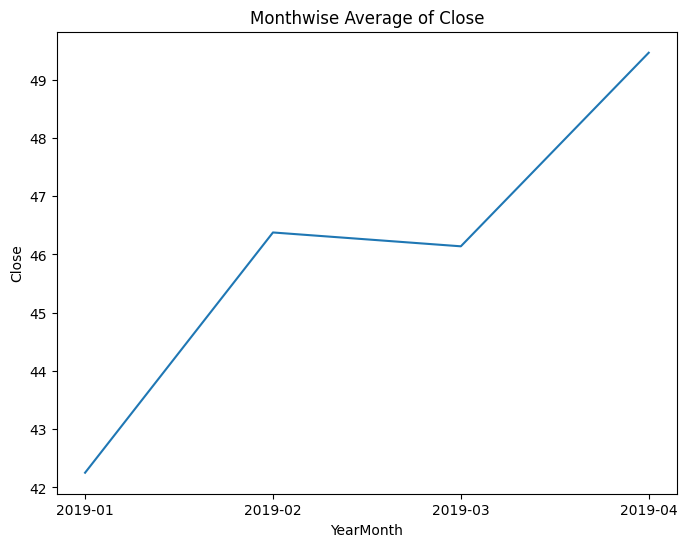

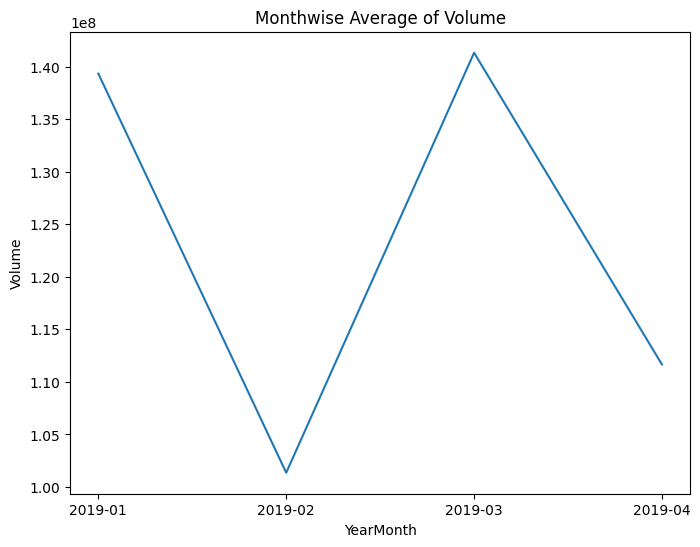

In [ ]:
# plot the monthwise averages of all price variables for better visualization
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.lineplot(x='YearMonth', y=col, data=monthwise_avg)
    plt.title(f'Monthwise Average of {col}')


* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

Text(0.5, 1.0, 'Monthwise Average of Volume')

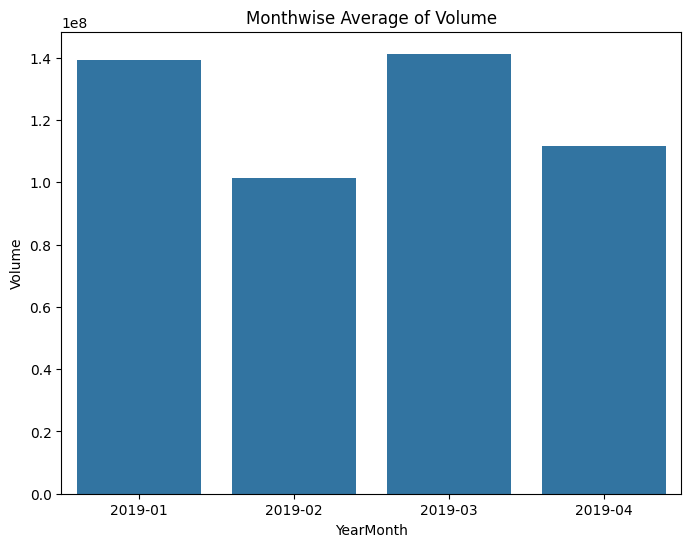

In [ ]:
#plot the trend of monthwise averages in Volume
plt.figure(figsize=(8, 6))
sns.barplot(x='YearMonth', y='Volume', data=monthwise_avg)
plt.title('Monthwise Average of Volume')

Text(0.5, 1.0, 'Monthwise Average of Volume')

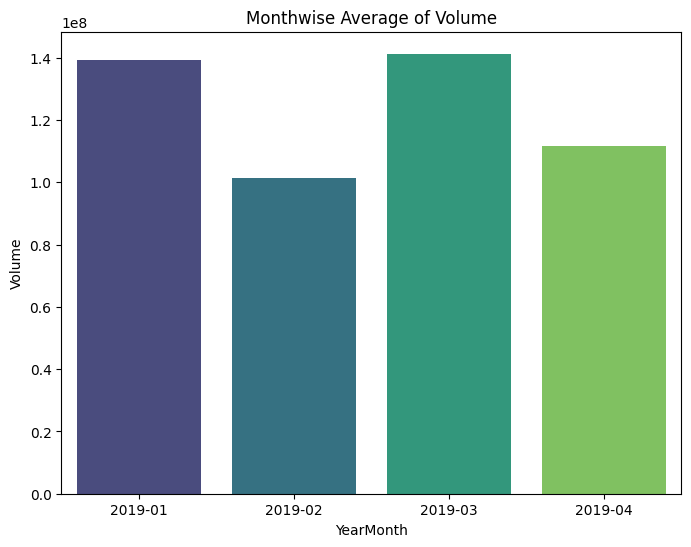

In [ ]:
# Bar plot of the monthwise averages in Volume
plt.figure(figsize=(8, 6))
sns.barplot(x='YearMonth', y='Volume', data=monthwise_avg,palette="viridis")
plt.title('Monthwise Average of Volume')

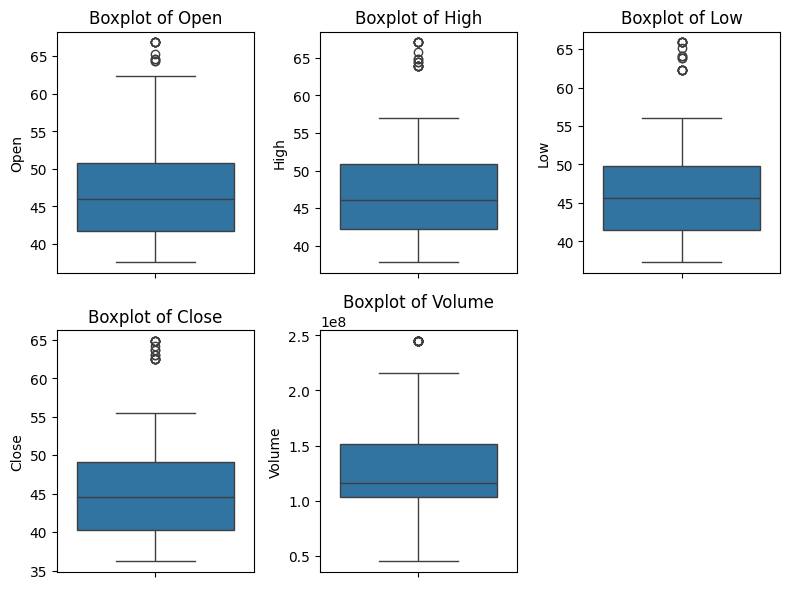

In [ ]:
# Boxplot to identify outliers
plt.figure(figsize=(8, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i) # Arrange plots in 2 rows, 3 columns
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

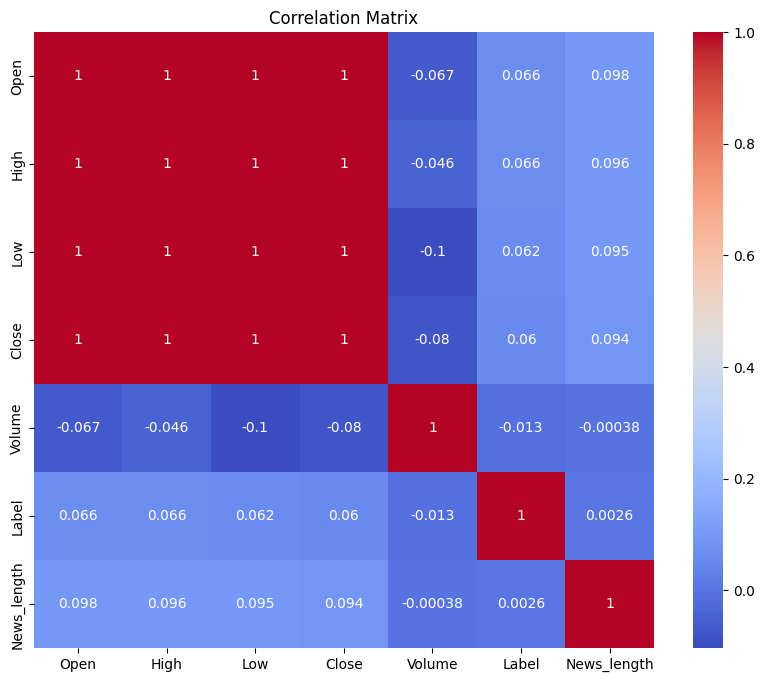

In [ ]:
# Correlation matrix to check if variables move together or have correlations
# Exclude non-numeric columns 'News' and 'Date' for correlation calculation
corr_matrix = data.drop(columns=['News', 'Date']).corr(numeric_only=True)

#create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### **Sentiment Polarity vs Price**

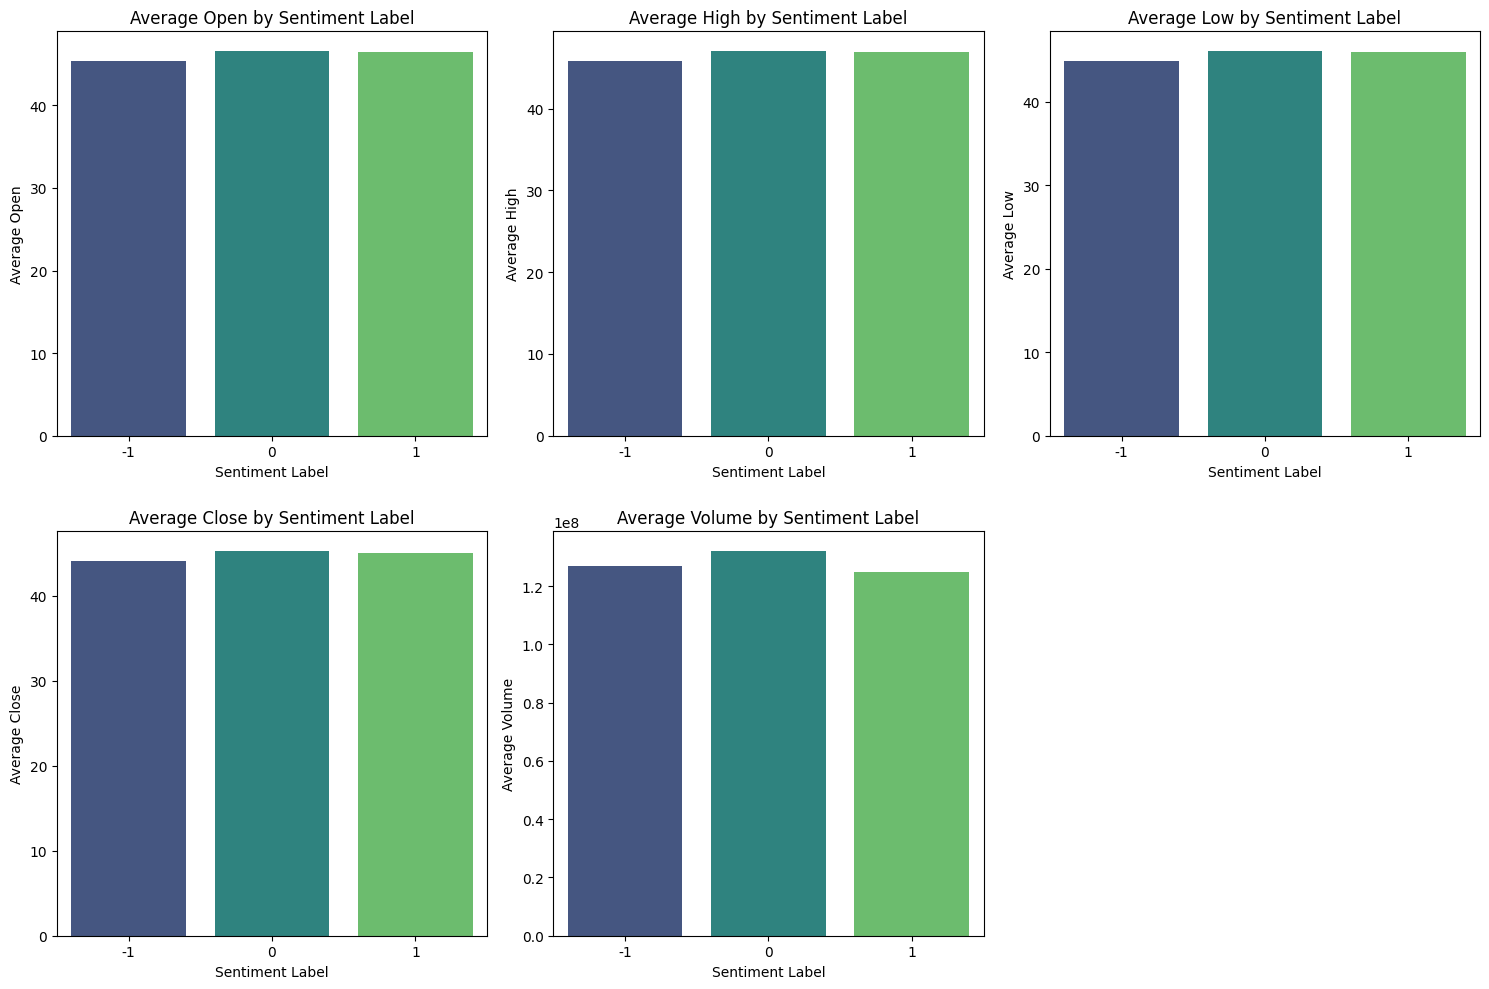

In [ ]:
#Sentiment Polarity with all numeric variables
sentiment_avg = data.groupby('Label')[['Open', 'High', 'Low', 'Close', 'Volume']].mean().reset_index()

plt.figure(figsize=(15, 10))
for i, col in enumerate(['Open', 'High', 'Low', 'Close', 'Volume'], 1):
    plt.subplot(2, 3, i)
    sns.barplot(x='Label', y=col, data=sentiment_avg, palette='viridis')
    plt.title(f'Average {col} by Sentiment Label')
    plt.xlabel('Sentiment Label')
    plt.ylabel(f'Average {col}')
plt.tight_layout()
plt.show()

### **Time Series Analysis (Date vs Price)**

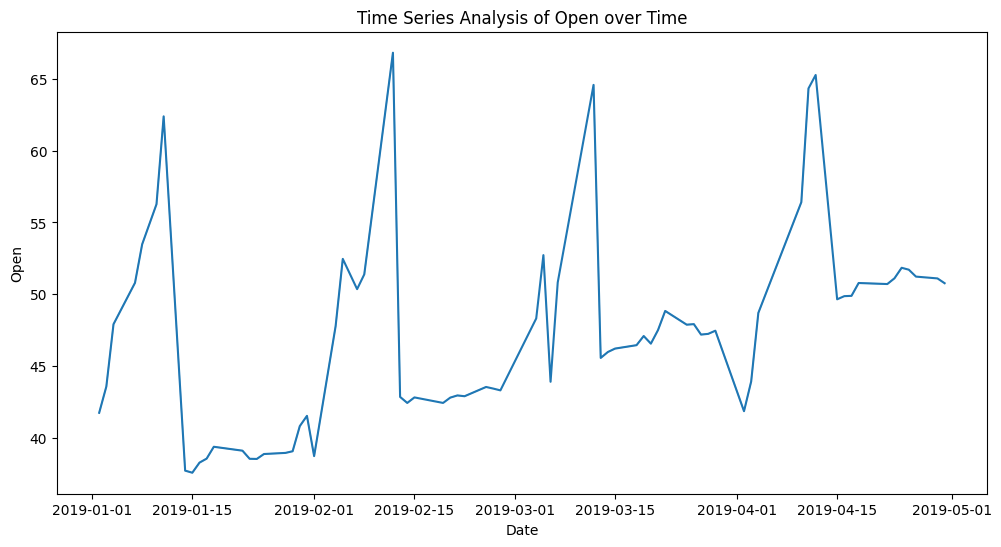

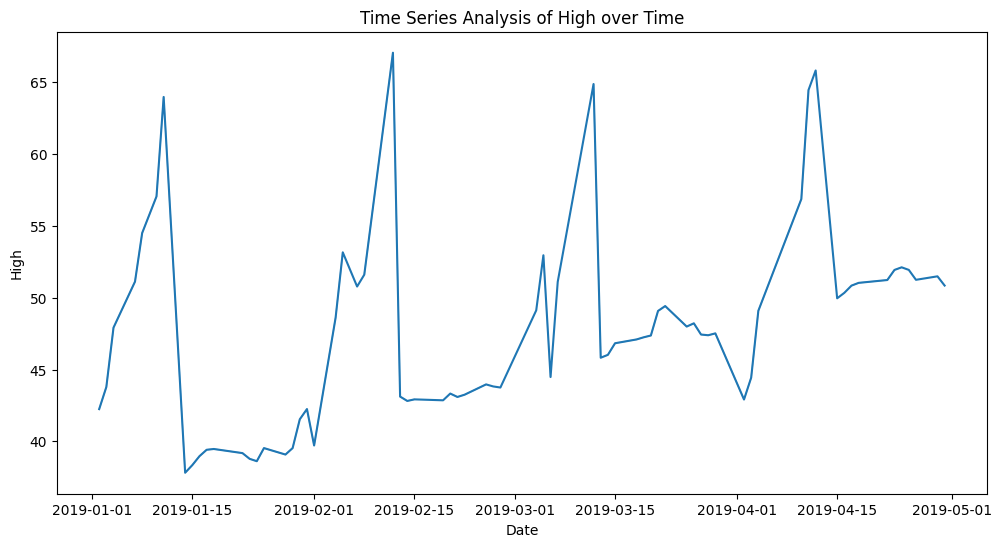

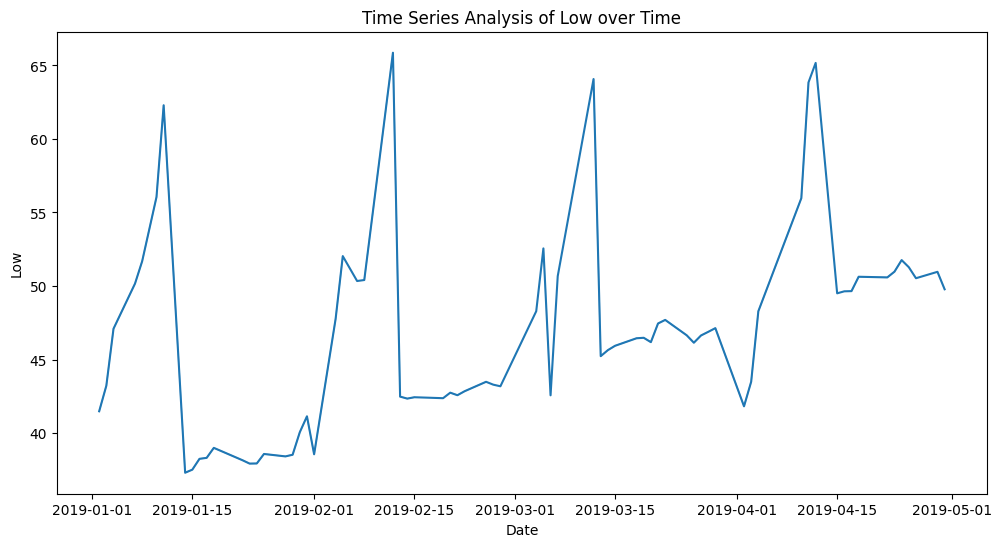

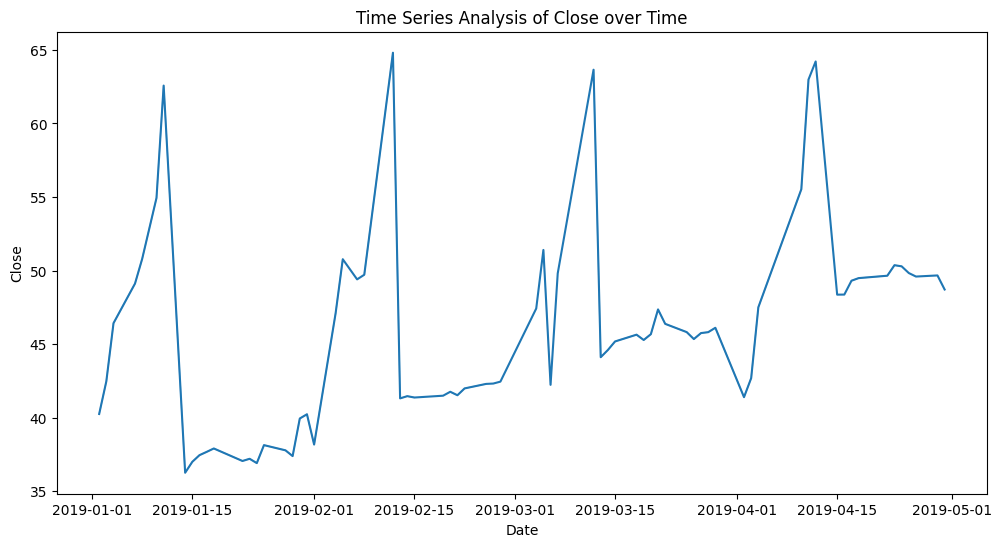

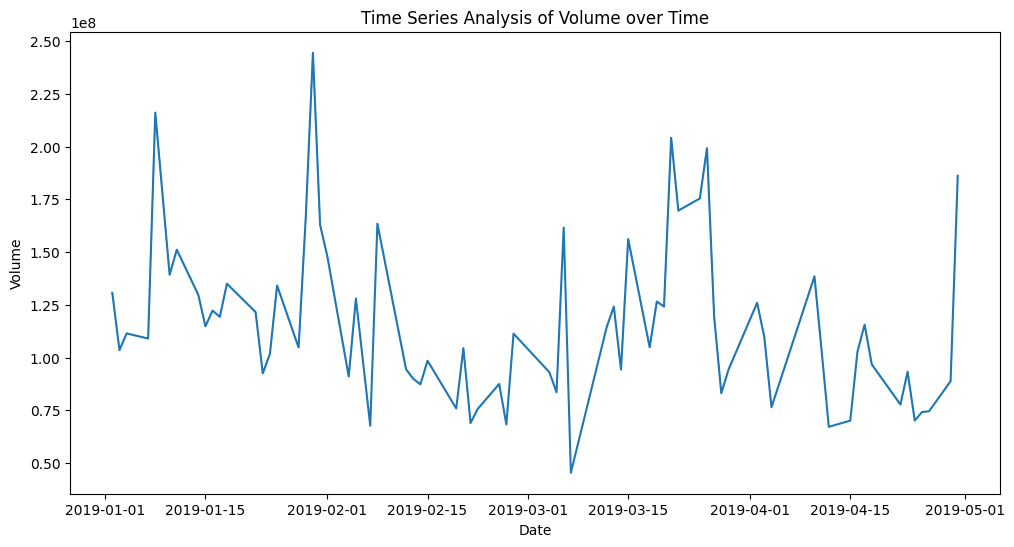

In [ ]:
#Time Series Analysis (Date vs Price columns)
for col in num_cols:
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Date', y=col, data=data)
    plt.title(f'Time Series Analysis of {col} over Time')
    plt.xlabel('Date')
    plt.ylabel(col)

### **Distribution of News Length Across Sentiment Categories**

Text(0.5, 1.0, 'Distribution of News Length Across Sentiment Categories')

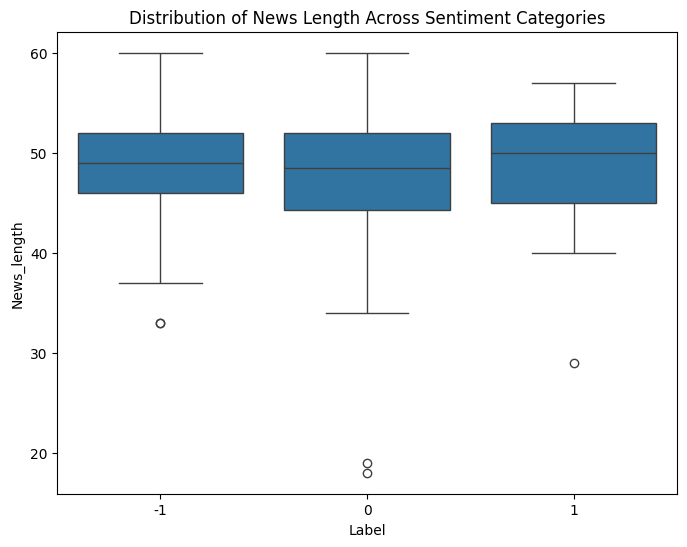

In [ ]:
# Distribution of News Length Across Sentiment Categories
plt.figure(figsize=(8, 6))
sns.boxplot(x='Label', y='News_length', data=data)
plt.title('Distribution of News Length Across Sentiment Categories')

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [ ]:
# Storing target variable
y = data['Label']

## **Word Embeddings**


#### **Word2Vec**

In [ ]:
# Creating a list of all words in our data
lst_words = []
for i in data['News']:
    lst_words.append(i.split())

In [ ]:
#creating an instance of word2vec
vec_size = 300
model_w2v = Word2Vec(lst_words, vector_size=vec_size, window=5, min_count=1, workers=6)

In [ ]:
#checking the size of the vocabulary
print("length of the vocabulary is",len(list(model_w2v.wv.key_to_index)))


length of the vocabulary is 4681


In [ ]:

# Retrieving word vectors for all the words present in the model's vocabulary
words=list(model_w2v.wv.key_to_index)
wvs=model_w2v.wv[words].tolist()

# Creating a dictionary of words and their corresponding vectors
word_vector_dict=dict()
for word,vector in zip(words,wvs):
  word_vector_dict[word]=vector

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [ ]:
# creating a dataframe of the vectorized documents

df_word2vec = pd.DataFrame(data['News'].apply(average_vectorizer_Word2Vec).tolist(),
columns=['feature'+str(i) for i in range(vec_size)])

df_word2vec.head()

,feature0,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,...,feature290,feature291,feature292,feature293,feature294,feature295,feature296,feature297,feature298,feature299
0,-0.002875,0.027398,0.004776,0.006541,-0.005204,-0.035313,0.026102,0.074380,0.012934,-0.018041,...,0.007435,0.036160,0.028352,0.005441,0.034185,0.036480,0.011160,-0.016250,0.026678,-0.016674
1,-0.002603,0.026504,0.004092,0.006630,-0.005153,-0.033760,0.025798,0.071333,0.012578,-0.017285,...,0.007388,0.034620,0.027785,0.005152,0.032099,0.035229,0.011007,-0.015269,0.025738,-0.016378
2,-0.002204,0.024569,0.003945,0.006153,-0.005109,-0.031192,0.023539,0.066727,0.011832,-0.016083,...,0.006245,0.032379,0.026163,0.004847,0.030046,0.032974,0.009870,-0.014089,0.024060,-0.015464
3,-0.002661,0.027804,0.004662,0.006310,-0.005290,-0.035847,0.027251,0.075366,0.012921,-0.018971,...,0.007780,0.036541,0.028842,0.005441,0.034079,0.037863,0.011118,-0.016297,0.026933,-0.017327
4,-0.002749,0.026490,0.004706,0.006416,-0.004966,-0.034243,0.025933,0.072298,0.013096,-0.017562,...,0.007530,0.035447,0.028513,0.005596,0.032861,0.035330,0.010796,-0.015691,0.025583,-0.016476


## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [ ]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

##### Encoding the dataset

In [ ]:
embedding_matrix = model.encode(data['News'])

In [ ]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 768)

## **Sentiment Analysis**

This cell introduces the 'Sentiment Analysis' section.

### **Model Evaluation Criterion**

This cell introduces the 'Model Evaluation Criterion' section.


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



This cell specifies the evaluation criteria for the models: plotting a confusion matrix and generating key classification metrics like accuracy, recall, precision, and F1-score.

##### **Utility Functions**

This cell introduces the 'Utility Functions' subsection, where helper functions for model evaluation are defined

In [ ]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

 The confusion matrix breaks down predictions by class, making it easy to spot which sentiment categories a model handles well and which ones it tends to confuse with each other. A model doing well will have most of its predictions concentrated on the diagonal.


In [ ]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

This cell defines the model_performance_classification_sklearn function, which calculates and returns a pandas DataFrame containing Accuracy, Recall, Precision, and F1-score for a given set of actual and predicted labels. This function will be used to quantify model performance.



*  The classification report provides Precision, Recall, and F1-score for each sentiment class. Higher values indicate better classification performance and balanced prediction across all classes.



This cell explains how to interpret the classification report metrics: higher values for Precision, Recall, and F1-score across sentiment classes indicate better and more balanced classification performance.

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [ ]:
# Storing independent variable
X = df_word2vec.copy()

#storing target variable
y= data['Label']

This cell assigns the df_Word2Vec (Word2Vec embeddings) to the independent variable X and the data.Label (sentiment polarity) to the target variable y for the Word2Vec-Random Forest model.

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

This cell splits the data (X and y) into training and testing sets using a 80:20 ratio (test_size = 0.2) and ensures reproducibility with random_state = 42.

In [ ]:
# Building the model
rf_word2vec = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)
# Fitting on train data
rf_word2vec.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

This cell initializes a RandomForestClassifier with 100 estimators and a maximum depth of 3, then fits the model to the training data (X_train, y_train).

In [ ]:
# Predicting on train data
y_pred_train = rf_word2vec.predict(X_train)

# Predicting on test data
y_pred_test = rf_word2vec.predict(X_test)

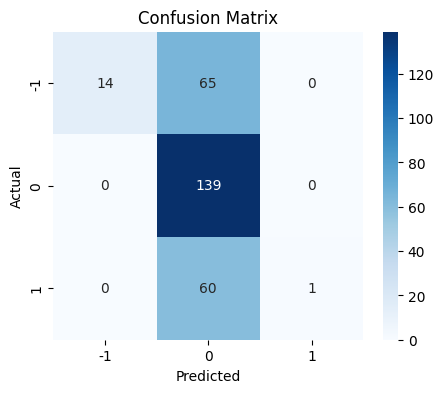

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

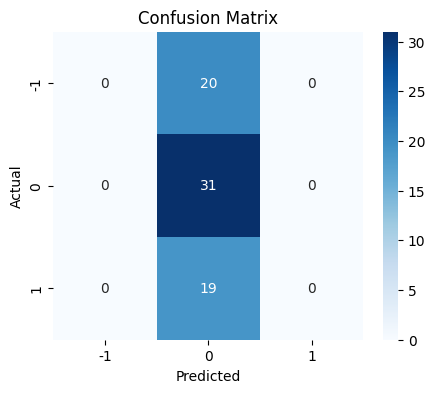

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

In [ ]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision      F1
 0.551971 0.551971   0.764106 0.43598
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


###**Sentence Transformer-Random Forest Model**

In [ ]:
# Storing independent variable
X = embedding_matrix

# Storing target variable
y = data["Label"]

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Building the model
rf_transformer = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

In [ ]:
# Predicting on train data
y_pred_train = rf_transformer.predict(X_train)

# Predicting on test data
y_pred_test = rf_transformer.predict(X_test)

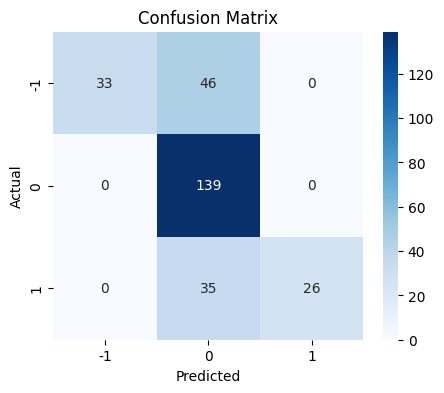

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

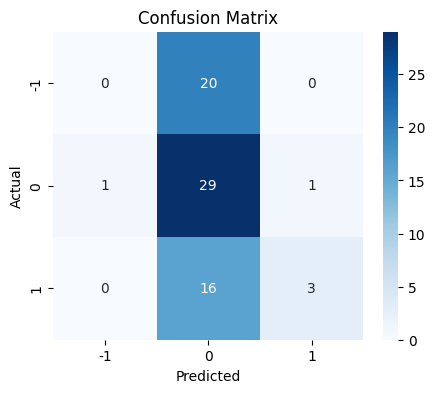

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

In [ ]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.709677 0.709677   0.816569 0.683338
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.457143 0.457143   0.401154 0.338367


### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [ ]:
# Storing independent variable
X = df_Word2Vec.copy()

# Storing target variable
y = data.Label

NameError: name 'df_Word2Vec' is not defined

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [ ]:

 # 3 output neurons for 3 classes
 import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

# Model definition
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']

)

model.summary()


In [ ]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

In [ ]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

In [ ]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [ ]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))


  # 3 output neurons for 3 classes

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']

)

model.summary()

In [ ]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

In [ ]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

In [ ]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [ ]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


# Sentence Transformer-2

# Generating Embeddings with Sentence Tranformers using the all-MiniLM-L6-v2 text embedding

In [1]:
# defining the model
MiniLM_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

NameError: name 'SentenceTransformer' is not defined

Sentence Transformer-Random Forest Model

In [ ]:
# Storing independent variable
X = embedding_matrix

# Storing target variable
y = data["Label"]

In [ ]:
# Split data into training and testing set.
X_train_MiniLM, X_test_MiniLM, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Building the model
rf_transformer_MiniLM = RandomForestClassifier(n_estimators = 100, max_depth = 3, random_state = 42)

# Fitting on train data
rf_transformer_MiniLM.fit(X_train_MiniLM, y_train)

In [ ]:
#Predicting the model on training data
y_pred_train = rf_transformer_MiniLM.predict(X_train_MiniLM)

#Predicting the model on test data
y_pred_test = rf_transformer_MiniLM.predict(X_test_MiniLM)

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

In [ ]:
train_transformer_MiniLM_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_MiniLM_RF.to_string(index=False))
test_transformer_MiniLM_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_MiniLM_RF.to_string(index=False))

# Sentence Transformer-Neural Network

In [ ]:
# Generate MiniLM embeddings
MiniLM_embeddings = MiniLM_model.encode(data['News'])

# Split the data into training and testing data
X_train_MiniLM, X_test_MiniLM, y_train, y_test = train_test_split(MiniLM_embeddings, y, test_size=0.2, random_state=42)

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train_MiniLM.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Since labels are integers
    metrics=['accuracy']
)

# Summary
model.summary()

In [ ]:
#Fitting the model
history = model.fit(
    X_train_MiniLM, y_train_mapped,
    validation_data=(X_test_MiniLM, y_test_mapped),
    epochs=20,
    batch_size=32
)

In [ ]:
#Predicting class probablities on training data
y_train_pred_probs = model.predict(X_train_MiniLM)

#Converting probabilities to class labels
y_train_preds = tf.argmax(y_train_pred_probs, axis=1).numpy()

In [ ]:
#Prdeicting probabilities on testing data
y_test_pred_probs = model.predict(X_test_MiniLM)

#Converting probabilities to class labels
y_test_preds = tf.argmax(y_test_pred_probs, axis=1).numpy()

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [ ]:
train_transformer_MiniLM_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_MiniLM_NN .to_string(index=False))
test_transformer_MiniLM_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_MiniLM_NN .to_string(index=False))

### **Model Performance Summary and Final Model Selection**

In [ ]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        train_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

In [ ]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        test_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

- Across the six model/embedding combinations tested, the **MiniLM + Neural Network** pairing comes out on top on **accuracy (58.57%)**, **recall (58.57%)**, and **F1-score (57.48%)**.
- **MiniLM + Random Forest** actually posts the best precision (75.90%), but its much weaker recall and F1-score mean it misses a lot of true positives — a reminder that precision alone isn't enough to pick a winning model when recall lags behind it.

# Prediction for unseen data

## **Implementation of the Best Model: SentenceTransformer (all-MiniLM-L6-v2) + Neural Network**

In [ ]:
# Import SentenceTransformer if not already imported (safe guard)
from sentence_transformers import SentenceTransformer

# Defining the MiniLM model
MiniLM_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

In [ ]:
# Generating embeddings with the MiniLM model
MiniLM_embeddings = MiniLM_model.encode(data['News'])

# Storing independent variable (embeddings)
X_best = MiniLM_embeddings

# Storing target variable
y_best = data['Label']

# Split data into training and testing set.
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(X_best ,y_best, test_size = 0.2, random_state = 42)

In [ ]:
# Map original labels (-1, 0, 1) to (0, 1, 2) for sparse_categorical_crossentropy
label_map = {-1: 0, 0: 1, 1: 2}
y_train_best_mapped = np.array([label_map[y] for y in y_train_best])
y_test_best_mapped = np.array([label_map[y] for y in y_test_best])

In [ ]:
import gc

# Clear previous Keras sessions to avoid memory issues and ensure a fresh model instance
tf.keras.backend.clear_session()
gc.collect()

# Build the Neural Network model
best_model_nn = Sequential()
best_model_nn.add(Dense(128, activation='relu', input_shape=(X_train_best.shape[1],)))
best_model_nn.add(Dropout(0.3))
best_model_nn.add(Dense(64, activation='relu'))
best_model_nn.add(Dense(3, activation='softmax')) # 3 output neurons for 3 classes

# Compile the model
best_model_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

# Display model summary
best_model_nn.summary()

In [ ]:
# Train the Neural Network model
history_best_model = best_model_nn.fit(
    X_train_best, y_train_best_mapped,
    validation_data=(X_test_best, y_test_best_mapped),
    epochs=20,
    batch_size=32,
    verbose=1
)

### **Evaluation of the Best Model**

In [ ]:
# Predict class probabilities on training data
y_train_pred_probs_best = best_model_nn.predict(X_train_best)

# Convert probabilities to class labels
y_train_preds_best = tf.argmax(y_train_pred_probs_best, axis=1).numpy()

In [ ]:
# Predict class probabilities on test data
y_test_pred_probs_best = best_model_nn.predict(X_test_best)

# Convert probabilities to class labels
y_test_preds_best = tf.argmax(y_test_pred_probs_best, axis=1).numpy()

In [ ]:
# Plot confusion matrix for training set
plot_confusion_matrix(y_train_best_mapped, y_train_preds_best)

In [ ]:
# Plot confusion matrix for test set
plot_confusion_matrix(y_test_best_mapped, y_test_preds_best)

In [ ]:
# Calculate and print performance metrics for training set
train_best_model_nn = model_performance_classification_sklearn(y_train_best_mapped, y_train_preds_best)
print("Training set performance metrics (Best Model):")
print(train_best_model_nn.to_string(index=False))

# Calculate and print performance metrics for test set
test_best_model_nn = model_performance_classification_sklearn(y_test_best_mapped, y_test_preds_best)
print("Test set performance metrics (Best Model): ")
print(test_best_model_nn.to_string(index=False))

## **Conclusions and Recommendations**

Six embedding-and-model combinations were built and compared for this sentiment classification task. In general, the sentence-transformer embeddings (which encode meaning at the sentence level) outperformed Word2Vec (which averages word-level vectors), and the neural network classifiers tended to make better use of that richer representation than Random Forest did. The strongest combination overall was:

- **Model:** SentenceTransformer (all-MiniLM-L6-v2) + Neural Network
- **Accuracy:** 0.5857
- **Precision:** 0.6062
- **Recall:** 0.5857
- **F1-Score:** 0.5748

#### **Conclusions**

**Word2Vec**

* Word2Vec learns a vector for each individual word based on the words that tend to surround it, then those word vectors are averaged to represent a full news article. It's a lightweight approach, but it loses word order and can't distinguish between different meanings of the same word.

**Sentence Transformer embeddings**

> BAAI/bge-base-en-v1.5:
* This model encodes an entire article as a single vector that reflects its overall meaning, rather than encoding words independently and averaging afterward — which generally gives it a richer, more context-aware representation than Word2Vec.

> all-MiniLM-L6-v2:
* A smaller, faster sentence-transformer variant that still captures meaningful sentence-level semantics while being cheaper to run — a good fit when speed matters at scale.

**Neural Networks**
* With several hidden layers, the neural network can learn non-linear combinations of embedding features, which helps it pick up on subtler sentiment cues than a purely linear approach would catch.

**Random Forest**
* Random Forest builds many decision trees on different subsets of the data and averages their votes, which tends to make it fairly stable and resistant to overfitting, though it doesn't always exploit high-dimensional embeddings as effectively as a neural network can.

#### **Recommendations**

 ### **Best Model Recommendation**

**Sentence Transformer (all-MiniLM-L6-v2) + Neural Network**

- This combination had the best test-set accuracy and F1-score of all six models tried, meaning it balances catching true sentiment signals against avoiding false ones better than the alternatives.
- The MiniLM embeddings give the model a compact but semantically rich view of each article, and the neural network is able to make good use of that representation through its non-linear layers.
- Given this balance of performance and efficiency, it's the combination best suited for deployment on new, unseen stock news going forward.
